In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

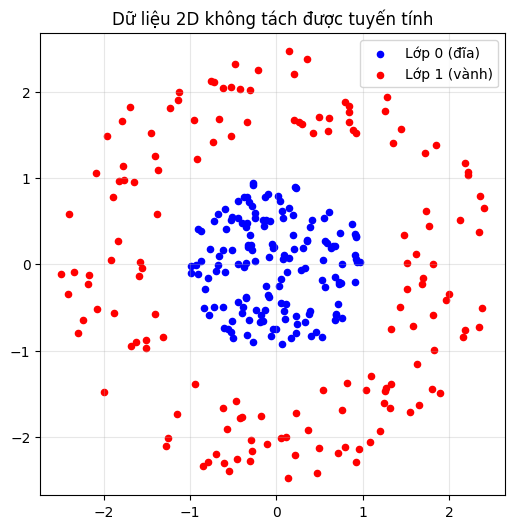

In [46]:
def gen_disk(n, r_max=1.0):
    u = np.random.uniform(0, 1, n)
    theta = np.random.uniform(0, 2 * np.pi, n)
    r = r_max * np.sqrt(u)
    return np.column_stack((r * np.cos(theta), r * np.sin(theta)))

def gen_ring(n, r_in=1.5, r_out=2.5):
    u = np.random.uniform(0, 1, n)
    theta = np.random.uniform(0, 2 * np.pi, n)
    r = np.sqrt(u * (r_out**2 - r_in**2) + r_in**2)
    return np.column_stack((r * np.cos(theta), r * np.sin(theta)))

n_per_class = 150
X0 = gen_disk(n_per_class)
X1 = gen_ring(n_per_class)
X = np.vstack([X0, X1])
y = np.hstack([np.zeros(n_per_class), np.ones(n_per_class)])

plt.figure(figsize=(6, 6))
plt.scatter(X0[:, 0], X0[:, 1], color='blue', label='Lớp 0 (đĩa)', s=20)
plt.scatter(X1[:, 0], X1[:, 1], color='red',  label='Lớp 1 (vành)', s=20)
plt.legend(); plt.axis('equal'); plt.grid(alpha=0.3)
plt.title('Dữ liệu 2D không tách được tuyến tính')
plt.show()

In [47]:
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train = torch.FloatTensor(X_train_np)
y_train = torch.FloatTensor(y_train_np).unsqueeze(1)
X_test  = torch.FloatTensor(X_test_np)
y_test  = torch.FloatTensor(y_test_np).unsqueeze(1)

print(f'Train: {len(X_train)} điểm,  Test: {len(X_test)} điểm')

Train: 240 điểm,  Test: 60 điểm


**Phần 1: Thay đổi cấu trúc ANN**




In [48]:
epochs = 500

def train_model(model, criterion, optimizer, X_train, y_train, X_test, y_test, epochs):
  loss_history, acc_history = [], []

  for epoch in range(epochs):
      model.train()
      optimizer.zero_grad()
      outputs = model(X_train)
      loss = criterion(outputs, y_train)
      loss.backward()
      optimizer.step()

      model.eval()
      with torch.no_grad():
          test_pred = (model(X_test) > 0.5).float()
          acc = (test_pred == y_test).float().mean().item()
      loss_history.append(loss.item())
      acc_history.append(acc)

      if (epoch + 1) % 100 == 0:
          print(f'Epoch {epoch+1:4d}/{epochs}  loss={loss.item():.4f}  test_acc={acc*100:.2f}%')

  fig, axes = plt.subplots(1, 2, figsize=(11, 4))
  axes[0].plot(loss_history); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].grid(alpha=0.3)
  axes[0].set_title('BCE loss')
  axes[1].plot([a*100 for a in acc_history]); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test acc (%)'); axes[1].grid(alpha=0.3)
  axes[1].set_title('Test accuracy')
  plt.tight_layout(); plt.show()

**Tăng số nút ẩn:** đổi lớp ẩn từ 4 nút thành 8 nút. Train 500 epoch. Ghi loss cuối, test accuracy.

Xây dựng ANN

Kiến trúc: 2 → 4 (ReLU) → 1 (Sigmoid).

ANN(
  (layer1): Linear(in_features=2, out_features=4, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=4, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)
Epoch  100/500  loss=0.3440  test_acc=85.00%
Epoch  200/500  loss=0.1295  test_acc=100.00%
Epoch  300/500  loss=0.0699  test_acc=100.00%
Epoch  400/500  loss=0.0439  test_acc=100.00%
Epoch  500/500  loss=0.0303  test_acc=100.00%


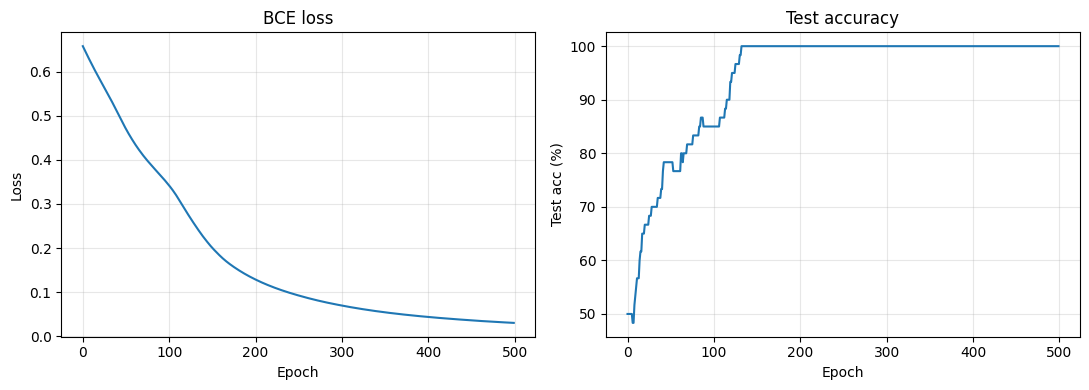

In [50]:
class ANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 4)
        self.relu   = nn.ReLU()
        self.layer2 = nn.Linear(4, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return self.sigmoid(self.layer2(self.relu(self.layer1(x))))

model = ANN()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
print(model)
train_model(model, criterion, optimizer, X_train, y_train, X_test, y_test, epochs)

ANN_8nut(
  (layer1): Linear(in_features=2, out_features=8, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=8, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)
Epoch  100/500  loss=0.1472  test_acc=98.33%
Epoch  200/500  loss=0.0358  test_acc=100.00%
Epoch  300/500  loss=0.0175  test_acc=100.00%
Epoch  400/500  loss=0.0099  test_acc=100.00%
Epoch  500/500  loss=0.0065  test_acc=100.00%


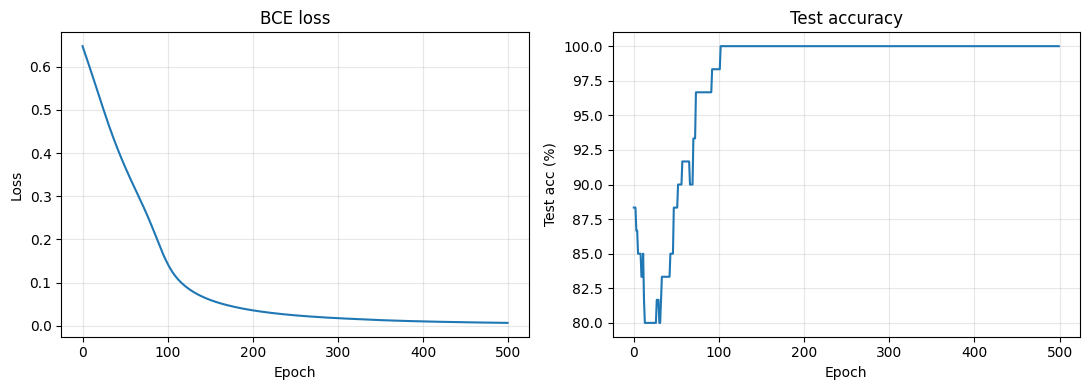

In [60]:
class ANN_8nut(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 8)
        self.relu   = nn.ReLU()
        self.layer2 = nn.Linear(8, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return self.sigmoid(self.layer2(self.relu(self.layer1(x))))

model_8nut = ANN_8nut()
criterion = nn.BCELoss()
optimizer = optim.Adam(model_8nut.parameters(), lr=0.01)
print(model_8nut)
train_model(model_8nut, criterion, optimizer, X_train, y_train, X_test, y_test, epochs)

**Thêm một lớp ẩn:** kiến trúc 2 → 8 (ReLU) → 6 (ReLU) → 1 (Sigmoid). Train 500 epoch.

ANN_3lop(
  (layer1): Linear(in_features=2, out_features=8, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=8, out_features=6, bias=True)
  (relu2): ReLU()
  (layer3): Linear(in_features=6, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)
Epoch  100/500  loss=0.1480  test_acc=100.00%
Epoch  200/500  loss=0.0031  test_acc=100.00%
Epoch  300/500  loss=0.0011  test_acc=100.00%
Epoch  400/500  loss=0.0006  test_acc=100.00%
Epoch  500/500  loss=0.0004  test_acc=100.00%


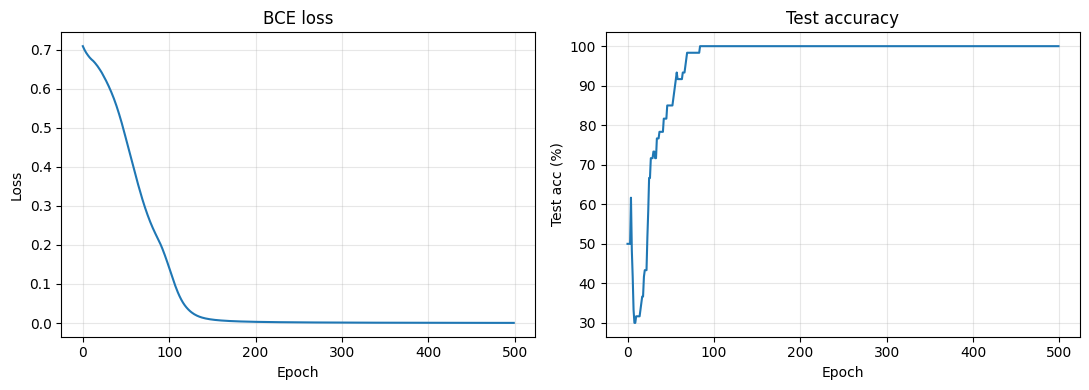

In [61]:
class ANN_3lop(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 8)
        self.relu   = nn.ReLU()
        self.layer2 = nn.Linear(8, 6)
        self.relu2  = nn.ReLU()
        self.layer3 = nn.Linear(6, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return self.sigmoid(self.layer3(self.relu2(self.layer2(self.relu(self.layer1(x))))))

ANN_3lop = ANN_3lop()
criterion = nn.BCELoss()
optimizer = optim.Adam(ANN_3lop.parameters(), lr=0.01)
print(ANN_3lop)
train_model(ANN_3lop, criterion, optimizer, X_train, y_train, X_test, y_test, epochs)

So sánh 3 mô hình (4 nút / 8 nút / 8+6 nút) trên cùng đồ thị loss. Câu hỏi:

Mô hình to hơn có giảm loss nhanh hơn không? Có overfitting không?

->có giảm loss nhanh hơn, không có bị overfitting vì overfitting xãy ra khi:Training loss tiếp tục giảm mạnh, Test accuracy giảm hoặc dao động xấu đi

Có hiện tượng diminishing returns (thêm nút không giúp thêm) không?

-> có bị diminishing returns

**Phần 2: Loss và Optimizer**

Đổi BCELoss thành BCEWithLogitsLoss: bỏ nn.Sigmoid khỏi model (BCEWithLogitsLoss tự xử lý). Train 500 epoch. Lưu ý: khi predict cần torch.sigmoid(output) > 0.5 chứ không phải output > 0.5.

In [51]:
epochs = 500

def train_model_1(model, criterion, optimizer, X_train, y_train, X_test, y_test, epochs):
  loss_history, acc_history = [], []

  for epoch in range(epochs):
      model.train()
      optimizer.zero_grad()
      outputs = model(X_train)
      loss = criterion(outputs, y_train)
      loss.backward()
      optimizer.step()

      model.eval()
      with torch.no_grad():
          logits = model(X_test)
          probs = torch.sigmoid(logits)
          pred = (probs > 0.5).float()
          acc = (pred == y_test).float().mean().item()
      loss_history.append(loss.item())
      acc_history.append(acc)

      if (epoch + 1) % 100 == 0:
          print(f'Epoch {epoch+1:4d}/{epochs}  loss={loss.item():.4f}  test_acc={acc*100:.2f}%')

  fig, axes = plt.subplots(1, 2, figsize=(11, 4))
  axes[0].plot(loss_history); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].grid(alpha=0.3)
  axes[0].set_title('BCE loss')
  axes[1].plot([a*100 for a in acc_history]); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test acc (%)'); axes[1].grid(alpha=0.3)
  axes[1].set_title('Test accuracy')
  plt.tight_layout(); plt.show()

ANN_Logits(
  (layer1): Linear(in_features=2, out_features=4, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=4, out_features=1, bias=True)
)
Epoch  100/500  loss=0.3022  test_acc=95.00%
Epoch  200/500  loss=0.1069  test_acc=100.00%
Epoch  300/500  loss=0.0552  test_acc=100.00%
Epoch  400/500  loss=0.0352  test_acc=100.00%
Epoch  500/500  loss=0.0247  test_acc=100.00%


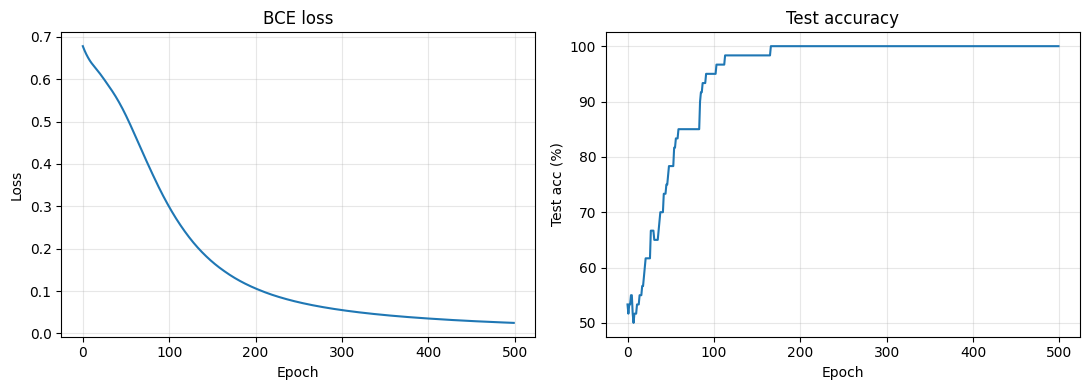

In [25]:
class ANN_Logits(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 4)
        self.relu   = nn.ReLU()
        self.layer2 = nn.Linear(4, 1)

    def forward(self, x):
        return self.layer2(
            self.relu(
                self.layer1(x)
            )
        )
model_logits = ANN_Logits()

criterion_logits = nn.BCEWithLogitsLoss()

optimizer_logits = optim.Adam(
    model_logits.parameters(),
    lr=0.01
)

print(model_logits)

train_model_1(
    model_logits,
    criterion_logits,
    optimizer_logits,
    X_train,
    y_train,
    X_test,
    y_test,
    epochs
)

Đổi Adam thành SGD (lr = 0.01, momentum = 0.9). Train 500 epoch. So sánh tốc độ hội tụ với Adam.

ANN(
  (layer1): Linear(in_features=2, out_features=4, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=4, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)
Epoch  100/500  loss=0.5356  test_acc=75.00%
Epoch  200/500  loss=0.3766  test_acc=93.33%
Epoch  300/500  loss=0.2628  test_acc=100.00%
Epoch  400/500  loss=0.1934  test_acc=100.00%
Epoch  500/500  loss=0.1520  test_acc=100.00%


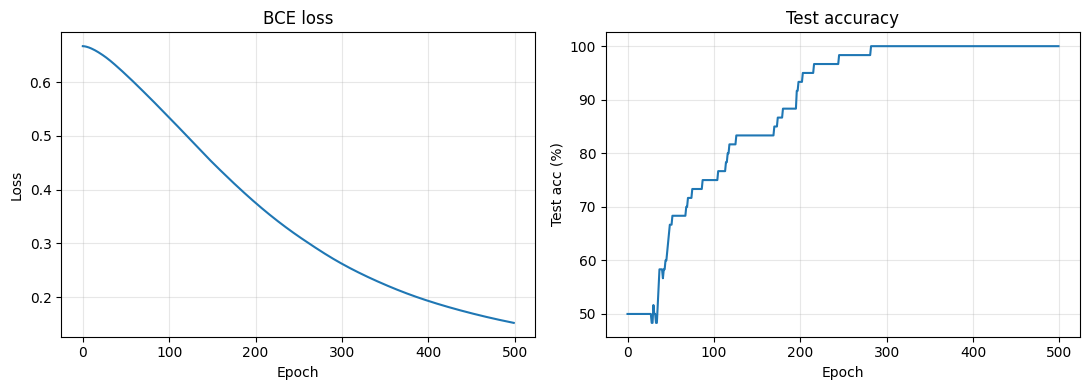

In [53]:
model_sgd = ANN()

criterion_sgd = nn.BCELoss()

optimizer_sgd = optim.SGD(
    model_sgd.parameters(),
    lr=0.01,
    momentum=0.9
)

print(model_sgd)

train_model(
    model_sgd,
    criterion_sgd,
    optimizer_sgd,
    X_train,
    y_train,
    X_test,
    y_test,
    epochs
)

Kết quả cho thấy Adam hội tụ nhanh hơn SGD trên cùng kiến trúc ANN và cùng bộ dữ liệu.
* Sau 100 epoch, Adam đạt loss 0.3366 và accuracy 93.33%, trong khi SGD vẫn còn loss 0.5897 và accuracy chỉ đạt 80%.
* Đến 200 epoch, Adam đã đạt accuracy 98.33% với loss 0.1224, còn SGD mới đạt 95% với loss 0.4209.
* Trong suốt quá trình huấn luyện, đường loss của Adam luôn thấp hơn đáng kể so với SGD, chứng tỏ Adam học nhanh hơn và tối ưu hiệu quả hơn.

Tuy nhiên, từ khoảng epoch 300 trở đi:

* Cả hai mô hình đều đạt accuracy 100%.
*  Mặc dù Adam vẫn có loss thấp hơn nhiều (0.0272 so với 0.1046 ở epoch 500), sự khác biệt về độ chính xác không còn đáng kể.

**Phần 3: Phân tích sâu**

Thử 3 learning rate: lr ∈ {0.001, 0.01, 0.1} với cấu trúc gốc. Vẽ 3 đường loss trên cùng đồ thị. Mô tả:

* lr nào quá nhỏ → học chậm?
* lr nào quá lớn → loss dao động hoặc nổ?

In [57]:
def run_experiment(lr):
    model = ANN()

    criterion = nn.BCELoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr
    )

    train_model(
        model,
        criterion,
        optimizer,
        X_train,
        y_train,
        X_test,
        y_test,
        epochs
    )

Epoch  100/500  loss=0.6448  test_acc=50.00%
Epoch  200/500  loss=0.6035  test_acc=50.00%
Epoch  300/500  loss=0.5608  test_acc=50.00%
Epoch  400/500  loss=0.5175  test_acc=65.00%
Epoch  500/500  loss=0.4750  test_acc=75.00%


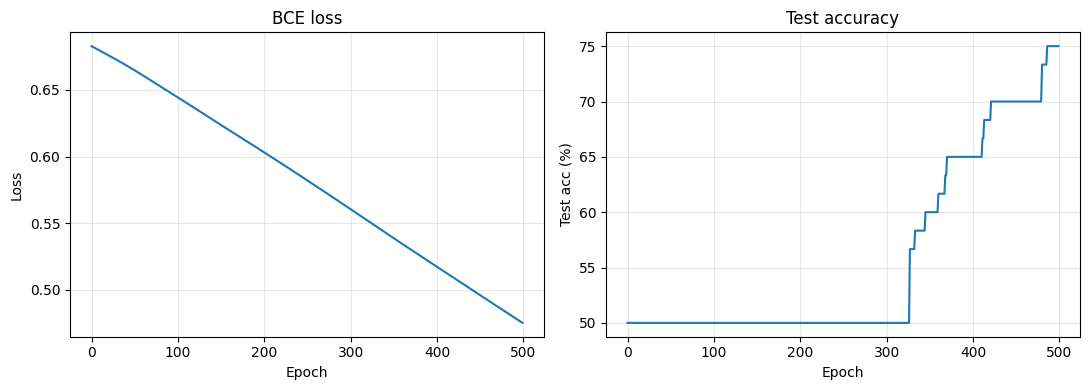

Epoch  100/500  loss=0.4366  test_acc=81.67%
Epoch  200/500  loss=0.2220  test_acc=96.67%
Epoch  300/500  loss=0.0816  test_acc=100.00%
Epoch  400/500  loss=0.0438  test_acc=100.00%
Epoch  500/500  loss=0.0284  test_acc=100.00%


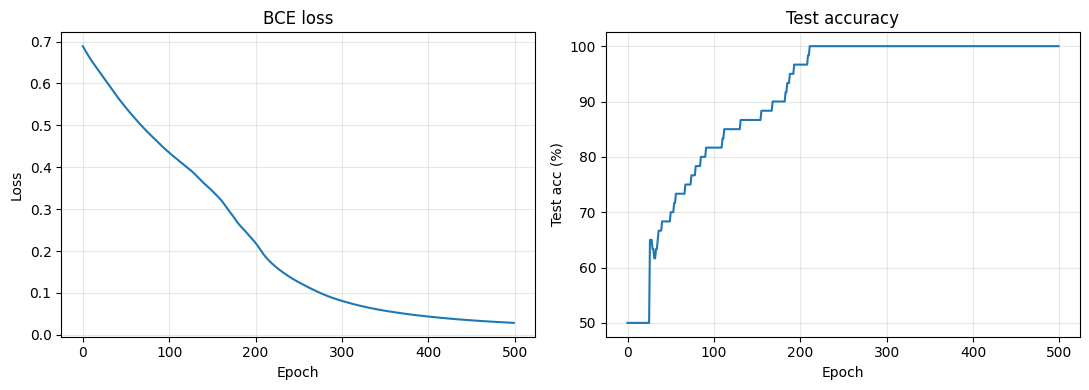

Epoch  100/500  loss=0.0098  test_acc=98.33%
Epoch  200/500  loss=0.0034  test_acc=100.00%
Epoch  300/500  loss=0.0019  test_acc=100.00%
Epoch  400/500  loss=0.0012  test_acc=100.00%
Epoch  500/500  loss=0.0009  test_acc=100.00%


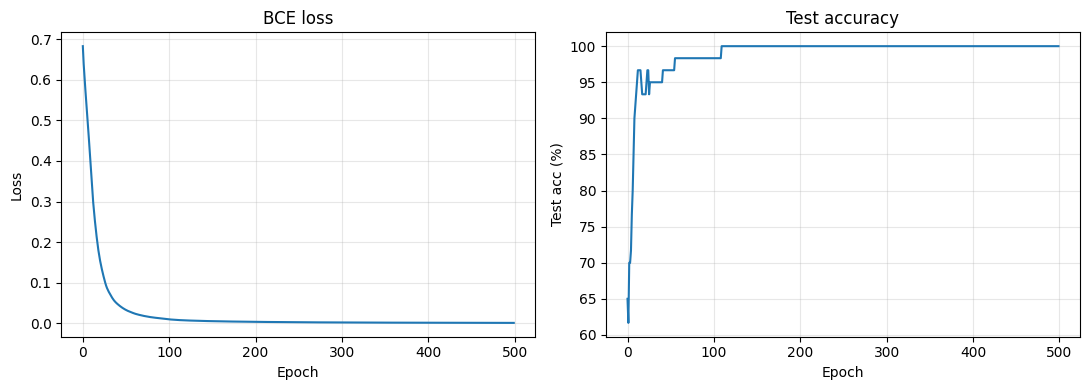

In [58]:
run_experiment(0.001)
run_experiment(0.01)
run_experiment(0.1)

* lr = 0.001 → học chậm hơn.
* lr = 0.01 → thường tốt nhất.
* lr = 0.1 → có thể dao động hoặc hội tụ kém.